In [ ]:
# Before applying on unseen material, doing an independent test set will help evlauatye the generalizability of the model,
# and what to expect, e.g. common problems such as duplicated bounding boxes. 
# For more indepth explanations behind the methods applied, see chapter 3. 

In [14]:
# Chunk 0 - imports and setup of directories
import json
import re
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO



def find_repo_root(start=None, marker=".git"):
    path = Path(start or Path.cwd()).resolve()
    for parent in [path, *path.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find a repo root (looking for '{marker}')")


REPO_ROOT = find_repo_root()

CONFIG = {
    # this is the annotated test set
    "HUMAN_ANNOTATIONS": REPO_ROOT / "use-a-crab-detector" / "data" / "test_predictions" / "annotations"/"instances_default.json",
    "TEST_IMAGES_DIR": REPO_ROOT / "use-a-crab-detector" / "data" / "test_predictions" / "images"/ "default",
    # change the model path if you are using another model
    "MODEL_PATH": REPO_ROOT / "use-a-crab-detector" / "model" / "pretrained-crab-detector" / "best.pt",
    "MODEL_PREDICTIONS": REPO_ROOT / "use-a-crab-detector" / "data" / "test_predictions" / "predictions.json",
    "OUTPUT_DIR": REPO_ROOT / "use-a-crab-detector" / "data" / "test_predictions" / "results",
    "THRESHOLDS": [0.0, 0.5, 0.75], # you can freely change, add or remove these as youd like
    "SAVE_ANNOTATED_IMAGES": False,  # set True to also save images with predicted boxes drawn in, for spot-checking

}
CONFIG["OUTPUT_DIR"].mkdir(parents=True, exist_ok=True)

In [15]:
# Chunk 1 - station helpers
# Matches the BRUV station ID out of a filename, e.g. "..._KV5_RA3_..." -> "KV5".
# Same convention used throughout the repo (see Chapter 1).
STATION_PATTERN = re.compile(r"_([A-Z]{2,3}\d{1,2})_(?:RA|B)\d{1,2}_[^/\\]*$", re.IGNORECASE)


def station_from_filename(fname: str) -> str | None:
    """Extract the BRUV station ID (e.g. 'KV5') from an image filename."""
    match = STATION_PATTERN.search(fname)
    return match.group(1) if match else None


def is_crab(annotation: dict, categories: dict) -> bool:
    """
    True only for annotations that are specifically a crab, not a hermit
    crab, lobster, or other Decapod species. Same exact-match logic as
    raw_to_yolo.ipynb, so counts stay consistent across the repo.
    """
    if categories.get(annotation.get("category_id"), "").lower() != "decapods":
        return False
    attrs = annotation.get("attributes") or {}
    species = str(attrs.get("Species") or attrs.get("species") or "").strip().lower()
    return species == "crab"


def calculate_iou(box1, box2) -> float:
    """Intersection-over-Union of two [x, y, width, height] boxes."""
    if not box1 or not box2:
        return 0.0
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    xi1, yi1 = max(x1, x2), max(y1, y2)
    xi2, yi2 = min(x1 + w1, x2 + w2), min(y1 + h1, y2 + h2)
    inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    union = w1 * h1 + w2 * h2 - inter
    return inter / union if union > 0 else 0.0


def deduplicate_predictions(preds: list, iou_threshold: float = 0.5) -> list:
    """
    Simple non-max suppression: when the model draws two overlapping boxes
    for what is really one crab, keep only the higher-confidence box.
    """
    preds_sorted = sorted(preds, key=lambda p: p.get("score", 0), reverse=True)
    kept = []
    for pred in preds_sorted:
        if not any(calculate_iou(pred.get("bbox"), k.get("bbox")) > iou_threshold for k in kept):
            kept.append(pred)
    return kept

In [16]:
# Chunk 2 - run the detector on the test-set images to generate predictions.json

def run_detector_on_test_images(images_dir: Path, model_path: Path, output_path: Path, save_annotated: bool = False) -> list:
    """
    Run the trained model on every image in images_dir and save the
    detections to output_path in the format the rest of this notebook
    expects. Runs on a folder of still images, not a video, so each
    prediction lines up exactly with the image a human already annotated
    (matched by filename).
    """
    model = YOLO(str(model_path))
    results = model.predict(
        source=str(images_dir),
        conf=0.1,
        imgsz=960,
        stream=True,
        verbose=False,
        save=save_annotated,
        project=str(output_path.parent / "annotated_images") if save_annotated else None,
        name="run",
        exist_ok=True,
    )

    predictions = []
    for result in results:
        image_id = Path(result.path).stem
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            predictions.append({
                "image_id": image_id,
                "score": float(box.conf[0]),
                "bbox": [x1, y1, x2 - x1, y2 - y1],
            })

    output_path.write_text(json.dumps(predictions, indent=2))
    print(f"Saved {len(predictions)} detections to {output_path}")
    return predictions


run_detector_on_test_images(
    CONFIG["TEST_IMAGES_DIR"], CONFIG["MODEL_PATH"], CONFIG["MODEL_PREDICTIONS"],
    save_annotated=CONFIG["SAVE_ANNOTATED_IMAGES"],
)

Saved 66 detections to /scratch/disk4/crab_model_gina/crabs-on-camera/use-a-crab-detector/data/test_predictions/predictions.json


[{'image_id': 'NO_2026_0108_GarnRuse_NordGjeslingan_NG4_RA3_L2_0005',
  'score': 0.6854787468910217,
  'bbox': [1115.329345703125,
   698.0477294921875,
   187.04345703125,
   209.7398681640625]},
 {'image_id': 'NO_2026_0108_GarnRuse_NordGjeslingan_NG4_RA3_L2_0006',
  'score': 0.8621957898139954,
  'bbox': [1105.2176513671875,
   714.7822265625,
   185.66162109375,
   204.8760986328125]},
 {'image_id': 'NO_2026_0108_GarnRuse_NordGjeslingan_NG4_RA3_L2_0007',
  'score': 0.887154757976532,
  'bbox': [1106.34765625, 722.7586669921875, 176.306640625, 216.296630859375]},
 {'image_id': 'NO_2026_0108_GarnRuse_NordGjeslingan_NG4_RA3_L2_0008',
  'score': 0.8748438954353333,
  'bbox': [1114.8375244140625,
   729.5535888671875,
   171.262451171875,
   217.060546875]},
 {'image_id': 'NO_2026_0108_GarnRuse_NordGjeslingan_NG4_RA3_L2_0009',
  'score': 0.8506923913955688,
  'bbox': [1096.518798828125, 699.366943359375, 132.69921875, 218.396484375]},
 {'image_id': 'NO_2026_0108_GarnRuse_NordGjeslingan_N

In [17]:
# Chunk 3 - per-station stats for the human-annotated ground truth
def summarize_by_station(counts_by_image: dict, images_by_station: dict, dataset_name: str) -> pd.DataFrame:
    """
    Turn a per-image crab count into per-station statistics: maxN (the
    single highest count seen at that station, a common index in BRUV
    survey work), meanN, medianN, and the spread (stdN).
    """
    rows = []
    for station, images in images_by_station.items():
        counts = [counts_by_image.get(img_id, 0) for img_id in images]
        rows.append({
            "station": station,
            "maxN": max(counts),
            "meanN": np.mean(counts),
            "medianN": np.median(counts),
            "stdN": np.std(counts),
            "total_images": len(counts),
            "total_crabs": sum(counts),
            "dataset": dataset_name,
        })
    return pd.DataFrame(rows).sort_values("station").reset_index(drop=True)


def process_human_annotations(coco_path: Path) -> pd.DataFrame:
    """Ground truth: per-station crab statistics from the human-annotated test set."""
    data = json.loads(coco_path.read_text(encoding="utf-8"))
    categories = {c["id"]: c.get("name", "") for c in data["categories"]}

    images_by_station = defaultdict(list)
    for img in data["images"]:
        station = station_from_filename(img.get("file_name", ""))
        if station:
            images_by_station[station].append(img["id"])

    crabs_per_image = Counter()
    for ann in data["annotations"]:
        if is_crab(ann, categories):
            crabs_per_image[ann["image_id"]] += 1

    return summarize_by_station(crabs_per_image, images_by_station, dataset_name="human_annotator")

In [33]:
# Chunk 4 - per stations stats for the model's predictions, at a given confidence thresholds

def process_predictions(coco_path: Path, pred_path: Path, confidence_threshold: float, apply_nms: bool = True) -> pd.DataFrame:
    """
    Model predictions at one confidence threshold, summarized the same
    way as the human annotations, so the two are directly comparable.

    Assumes predictions.json entries look like
    {"image_id": "<filename stem>", "score": <float>, "bbox": [...]}.
    """
    coco = json.loads(coco_path.read_text())
    preds = json.loads(pred_path.read_text())

    # Map each image's filename stem to its station, so predictions
    # (keyed by stem) can be grouped by station like the human data.
    stem_to_station = {}
    images_by_station = defaultdict(list)
    for img in coco["images"]:
        station = station_from_filename(img.get("file_name", ""))
        stem = Path(img["file_name"]).stem
        if station:
            stem_to_station[stem] = station
            images_by_station[station].append(stem)

    filtered = [p for p in preds if p.get("score", 0) >= confidence_threshold]

    preds_by_stem = defaultdict(list)
    for pred in filtered:
        stem = str(pred.get("image_id", ""))
        if stem in stem_to_station:
            preds_by_stem[stem].append(pred)

    if apply_nms:
        preds_by_stem = {stem: deduplicate_predictions(p) for stem, p in preds_by_stem.items()}

    crabs_per_stem = {stem: len(p) for stem, p in preds_by_stem.items()}

    return summarize_by_station(crabs_per_stem, images_by_station, dataset_name=f"model_thresh_{confidence_threshold}")

In [35]:
# Chunk 5 - compare model predictions against ground truth, across thresholds

def compare_to_human(df_human: pd.DataFrame, coco_path: Path, pred_path: Path, thresholds: list) -> tuple[dict, pd.DataFrame]:
    """
    For each confidence threshold: get the model's per-station stats and
    summarize how its totals, overall maxN, and average meanN compare to
    the human ground truth.
    """
    per_threshold_df = {}
    summary_rows = []

    for threshold in thresholds:
        df_pred = process_predictions(coco_path, pred_path, threshold)
        per_threshold_df[threshold] = df_pred

        summary_rows.append({
            "threshold": threshold,
            "total_human_crabs": df_human["total_crabs"].sum(),
            "total_predicted_crabs": df_pred["total_crabs"].sum(),
            # The single highest count seen in any one frame across all
            # stations, not an average of each station's peak.
            "human_maxN": df_human["maxN"].max(),
            "model_maxN": df_pred["maxN"].max(),
            "human_meanN": df_human["meanN"].mean(),
            "model_meanN": df_pred["meanN"].mean(),
        })

    return per_threshold_df, pd.DataFrame(summary_rows)

In [36]:
# Chunk 6 - barplots to visually compare the predictions and the human
def plot_threshold_comparison(summary_df: pd.DataFrame, output_path: Path) -> None:
    """Bar chart of the model's numbers per threshold, with the human ground truth as a reference line."""
    metrics = [
        ("total_human_crabs", "total_predicted_crabs", "Total crabs"),
        ("human_maxN", "model_maxN", "maxN"),
        ("human_meanN", "model_meanN", "Average meanN"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (human_col, model_col, title) in zip(axes, metrics):
        x = summary_df["threshold"].astype(str)
        ax.bar(x, summary_df[model_col], alpha=0.7, color="tab:blue", label="Model")
        ax.axhline(summary_df[human_col].iloc[0], color="green", linestyle="--", label="Human")
        ax.set_title(title)
        ax.set_xlabel("Confidence threshold")
        ax.legend()

    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()

   threshold  total_human_crabs  total_predicted_crabs  human_maxN  \
0       0.00                 40                     35           2   
1       0.50                 40                     31           2   
2       0.75                 40                     23           2   

   model_maxN  human_meanN  model_meanN  
0           2     0.155039     0.135659  
1           1     0.155039     0.120155  
2           1     0.155039     0.089147  


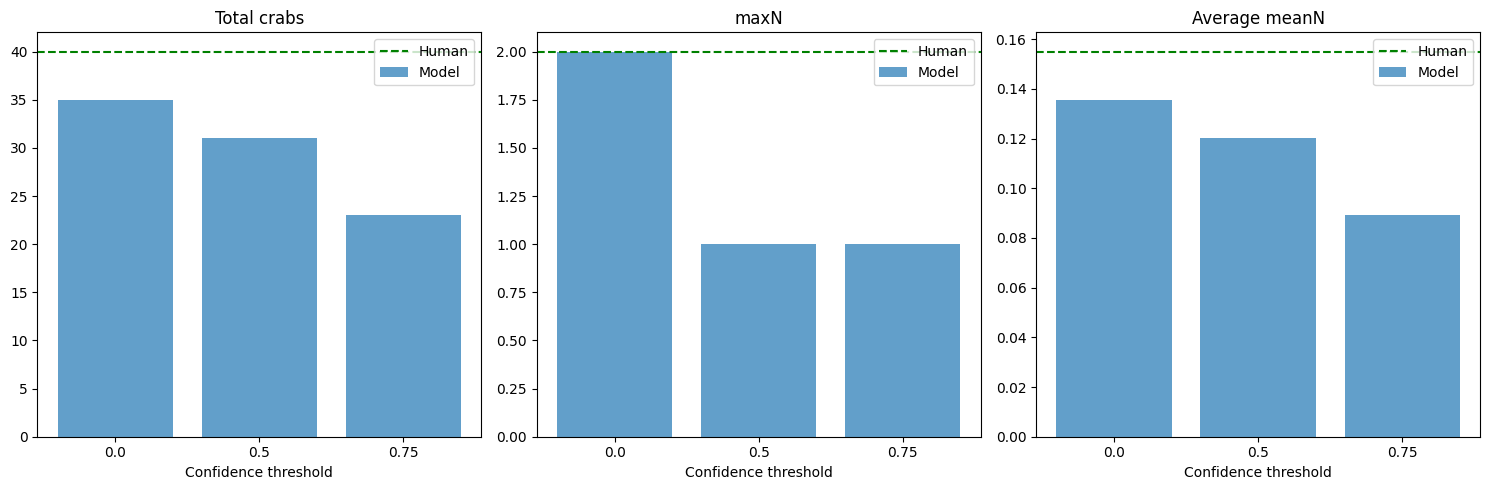

In [37]:
# Chunk 7 - run it and save CSV to use in R

df_human = process_human_annotations(CONFIG["HUMAN_ANNOTATIONS"])
per_threshold_df, summary_df = compare_to_human(df_human, CONFIG["HUMAN_ANNOTATIONS"], CONFIG["MODEL_PREDICTIONS"], CONFIG["THRESHOLDS"])

summary_df.to_csv(CONFIG["OUTPUT_DIR"] / "threshold_summary.csv", index=False)
print(summary_df)

plot_threshold_comparison(summary_df, CONFIG["OUTPUT_DIR"] / "threshold_comparison.png")